In [ ]:
#Manipulation de données
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#Visualisation
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

#Modèles et évaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Outils de pipeline et transformation
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

#Modèles de boosting
import xgboost as xgb
import lightgbm as lgb

In [2]:
# Charger les données si besoin puis nettoyer
if 'df' not in globals():
    df = pd.read_csv("../data/Telco-Customer-Churn.csv")
    print("Jeu de données importé")
else:
    # si df existe déjà, on repart de la copie fraîche pour éviter
    # transformations successives lors de reruns
    df = pd.read_csv("../data/Telco-Customer-Churn.csv")
    print("Jeu de données rechargé")
# toutes mes manipulations de type s'exécutent au cas où
# l'utilisateur relancerait la cellule plusieurs fois
# certaines colonnes numériques sont lues comme object (ex TotalCharges)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# suppression des lignes où TotalCharges est manquant
initial_shape = df.shape
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
if df.shape != initial_shape:
    print(f" - suppression de {initial_shape[0] - df.shape[0]} lignes sans TotalCharges")
print(f"Jeu de données final : {df.shape} lignes, {df.shape[1]} colonnes")


Jeu de données importé
 - suppression de 11 lignes sans TotalCharges
Jeu de données final : (7032, 21) lignes, 21 colonnes


# Objectif et contexte
Ce notebook consolide la démarche entreprise dans le premier document. Il s'agit de poursuivre l'exploration
préalable (notebook 01) en construisant des **modèles de scoring** pour la probabilité de churn, puis en
analysant leurs performances. L'emphase est mise sur la justification des choix méthodologiques et l'interprétation
des résultats.

La structure du notebook sera la suivante :

1. Préparation des données (nettoyage, encodage, normalisation) – ce chapitre est court car la majorité des
   traitements a été effectué dans le notebook 01.
2. **Régression logistique** – baseline linéaire et interprétable.
3. **XGBoost** – modèle boosté pour gagner en performance sur les interactions.
4. **Random Forest** – modèle bagging représentant un troisième point de comparaison.
5. Synthèse et conclusions : comparaison des modèles avec recommandations pour la suite.

Les algorithmes sont évalués selon les métriques classiques de classification (accuracy, F1, ROC AUC) et via
des matrices de confusion, conformément à la démarche décrite dans le README.

In [3]:
# Séparation des variables explicatives et de la variable cible
X = df.drop(columns=["Churn"])
# L'identifiant client n'apporte aucune information, on le retire
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])
# y doit être binaire pour la classification
# dans le fichier original Churn est 'Yes'/'No'
y = df["Churn"].map({"Yes": 1, "No": 0})

# Séparation des données en ensembles d'entraînement et de test avec stratification
set_seed = 1204
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=set_seed, stratify=y
)

# Affichage des dimensions du dataset
print("=" * 70)
print(" DIMENSIONS DES DONNÉES D'ENTRAÎNEMENT ")
print("=" * 70)
print(f"  -Varibales explicatives : (X_train) : {X_train.shape}")
print(f"  -Variable cible         : (y_train) : {y_train.shape}")

print("=" * 70)
print(" DIMENSIONS DES DONNÉES DE TEST ")
print("=" * 70)
print(f"  -Varibales explicatives : (X_test) : {X_test.shape}")
print(f"  -Variable cible         : (y_test) : {y_test.shape}")
print("=" * 70)


 DIMENSIONS DES DONNÉES D'ENTRAÎNEMENT 
  -Varibales explicatives : (X_train) : (5625, 19)
  -Variable cible         : (y_train) : (5625,)
 DIMENSIONS DES DONNÉES DE TEST 
  -Varibales explicatives : (X_test) : (1407, 19)
  -Variable cible         : (y_test) : (1407,)


In [4]:
#Création des listes de variables par catégorie
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
all_cols = X_train.columns.tolist()

print(f"La liste des {len(cat_cols)} variables catégorielles est : {cat_cols}\n")
print(f"La liste des {len(num_cols)} variables numériques est : {num_cols}\n")
print(f"La liste de toutes les variables est : {all_cols}\n")

La liste des 15 variables catégorielles est : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

La liste des 4 variables numériques est : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

La liste de toutes les variables est : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']



In [5]:
# Vérifier le type de TotalCharges
print("TotalCharges dtype :", X_train["TotalCharges"].dtype)


TotalCharges dtype : float64


In [ ]:
# Affichage des types de données et des valeurs manquantes pour les ensembles d'entraînement
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 5288 to 1245
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5625 non-null   object 
 1   SeniorCitizen     5625 non-null   int64  
 2   Partner           5625 non-null   object 
 3   Dependents        5625 non-null   object 
 4   tenure            5625 non-null   int64  
 5   PhoneService      5625 non-null   object 
 6   MultipleLines     5625 non-null   object 
 7   InternetService   5625 non-null   object 
 8   OnlineSecurity    5625 non-null   object 
 9   OnlineBackup      5625 non-null   object 
 10  DeviceProtection  5625 non-null   object 
 11  TechSupport       5625 non-null   object 
 12  StreamingTV       5625 non-null   object 
 13  StreamingMovies   5625 non-null   object 
 14  Contract          5625 non-null   object 
 15  PaperlessBilling  5625 non-null   object 
 16  PaymentMethod     5625 non-null   object 
 1

In [6]:
# Prétraitement des données
# On utilisera un ColumnTransformer pour scalers les quantitatifs et encoder les catégoriels.
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Le pipeline final sera construit avec le modèle sélectionné afin de garantir la reproductibilité des transformations lors des validations et tests.



## 1. Régression logistique par cross-validation

Nous commençons par un modèle simple et linéaire qui servira de référence. La
régression logistique est choisie pour sa facilité d'interprétation et sa rapidité
à être entraînée. Elle permettra également de détecter rapidement un éventuel
sur-apprentissage lorsque comparée aux modèles d'ensemble.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

print("🎯 RÉGRESSION LOGISTIQUE (Classification du churn)")
print("="*70)

# Pipeline (préprocessing + modèle)
log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000))
    ]
)

# ===============================
# 🔁 Cross Validation
# ===============================

print("\n🔁 Cross Validation (5 folds)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    log_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\n📊 Résultats Cross Validation (moyenne) :")
print(f"   Accuracy  : {cv_results['test_accuracy'].mean():.4f}")
print(f"   Precision : {cv_results['test_precision'].mean():.4f}")
print(f"   Recall    : {cv_results['test_recall'].mean():.4f}")
print(f"   F1-score  : {cv_results['test_f1'].mean():.4f}")
print(f"   ROC AUC   : {cv_results['test_roc_auc'].mean():.4f}")

# ===============================
# 🎓 Entraînement final
# ===============================

log_pipeline.fit(X_train, y_train)

# ===============================
# 🔮 Prédictions
# ===============================

y_pred_log_train = log_pipeline.predict(X_train)
y_pred_log_test = log_pipeline.predict(X_test)
y_proba_log_test = log_pipeline.predict_proba(X_test)[:, 1]

# ===============================
# 📊 Métriques
# ===============================

print("\n📊 Accuracy :")
print(f"   Train : {accuracy_score(y_train, y_pred_log_train):.4f}")
print(f"   Test  : {accuracy_score(y_test, y_pred_log_test):.4f}")

print("\nPrécision/Rappel/F1 (Test) :")
print(f"   Précision : {precision_score(y_test, y_pred_log_test):.4f}")
print(f"   Rappel    : {recall_score(y_test, y_pred_log_test):.4f}")
print(f"   F1        : {f1_score(y_test, y_pred_log_test):.4f}")

# ===============================
# 🔍 Matrice de confusion
# ===============================

cm = confusion_matrix(y_test, y_pred_log_test)

print("\n🔍 Matrice de confusion :")
print(f"   TN : {cm[0,0]} | FP : {cm[0,1]}")
print(f"   FN : {cm[1,0]} | TP : {cm[1,1]}")

# ===============================
# 📈 ROC AUC
# ===============================

auc = roc_auc_score(y_test, y_proba_log_test)

print(f"\nROC AUC (Test) : {auc:.4f}")

🎯 RÉGRESSION LOGISTIQUE (Classification du churn)

🔁 Cross Validation (5 folds)

📊 Résultats Cross Validation (moyenne) :
   Accuracy  : 0.8000
   Precision : 0.6496
   Recall    : 0.5385
   F1-score  : 0.5881
   ROC AUC   : 0.8411

📊 Accuracy :
   Train : 0.8046
   Test  : 0.8109

Précision/Rappel/F1 (Test) :
   Précision : 0.6849
   Rappel    : 0.5348
   F1        : 0.6006

🔍 Matrice de confusion :
   TN : 941 | FP : 92
   FN : 174 | TP : 200

ROC AUC (Test) : 0.8600



🔍 Matrice de confusion (Validation croisée) :
[[3705  425]
 [ 686  809]]


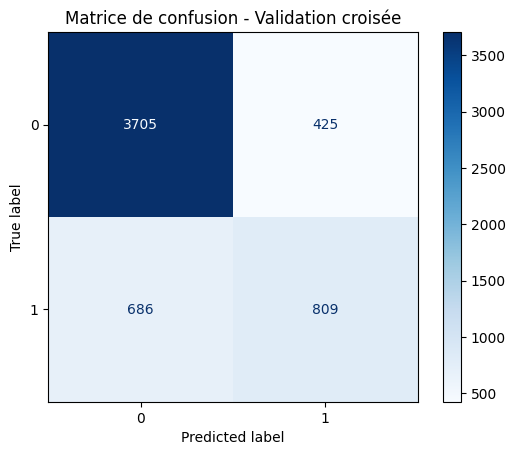

In [22]:
from sklearn.model_selection import cross_val_predict

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédictions avec validation croisée
y_pred_log_cv = cross_val_predict(log_pipeline, X_train, y_train, cv=5)

# Matrice de confusion pour les prédictions en validation croisée
matrice_confusion = confusion_matrix(y_train, y_pred_log_cv)
print("\n🔍 Matrice de confusion (Validation croisée) :")
print(matrice_confusion)

# Affichage de la matrice de confusion
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix=matrice_confusion, display_labels=log_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - Validation croisée")
plt.show()

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objects as go

# Exemple : score de décision pour la classe positive
scores_decision = log_pipeline.decision_function(X_train)
chiffre_cible = 1  # classe positive

# Calcul FPR, TPR et AUC
fpr, tpr, seuils_roc = roc_curve(y_train, scores_decision)
auc_score = roc_auc_score(y_train, scores_decision)

# Création figure interactive
fig = go.Figure()

# Courbe ROC
fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'SGD - Chiffre {chiffre_cible} (AUC = {auc_score:.3f})',
    line=dict(color='#011c5d', width=2),
    hovertemplate='<b>FPR</b>: %{x:.3f}<br><b>TPR (Recall)</b>: %{y:.3f}<extra></extra>'
))

# Ligne référence aléatoire
fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Classifieur aléatoire (AUC = 0.5)',
    line=dict(color='black', width=2, dash='dash'),
    hovertemplate='<b>FPR</b>: %{x:.3f}<br><b>TPR</b>: %{y:.3f}<extra></extra>'
))

# Layout
fig.update_layout(
    title={'text': 'Courbe ROC', 'font': {'size': 16}},
    xaxis_title='Taux de Faux Positifs (FPR)',
    yaxis_title='Taux de Vrais Positifs (TPR = Recall)',
    xaxis=dict(range=[0, 1], showgrid=True, gridcolor='rgba(128,128,128,0.2)'),
    yaxis=dict(range=[0, 1], showgrid=True, gridcolor='rgba(128,128,128,0.2)'),
    hovermode='closest',
    width=900,
    height=600,
    template='plotly_white',
    showlegend=True
)

fig.show()

print(f"\nAUC Score : {auc_score:.3f}")


AUC Score : 0.844


In [32]:
print(X_train.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


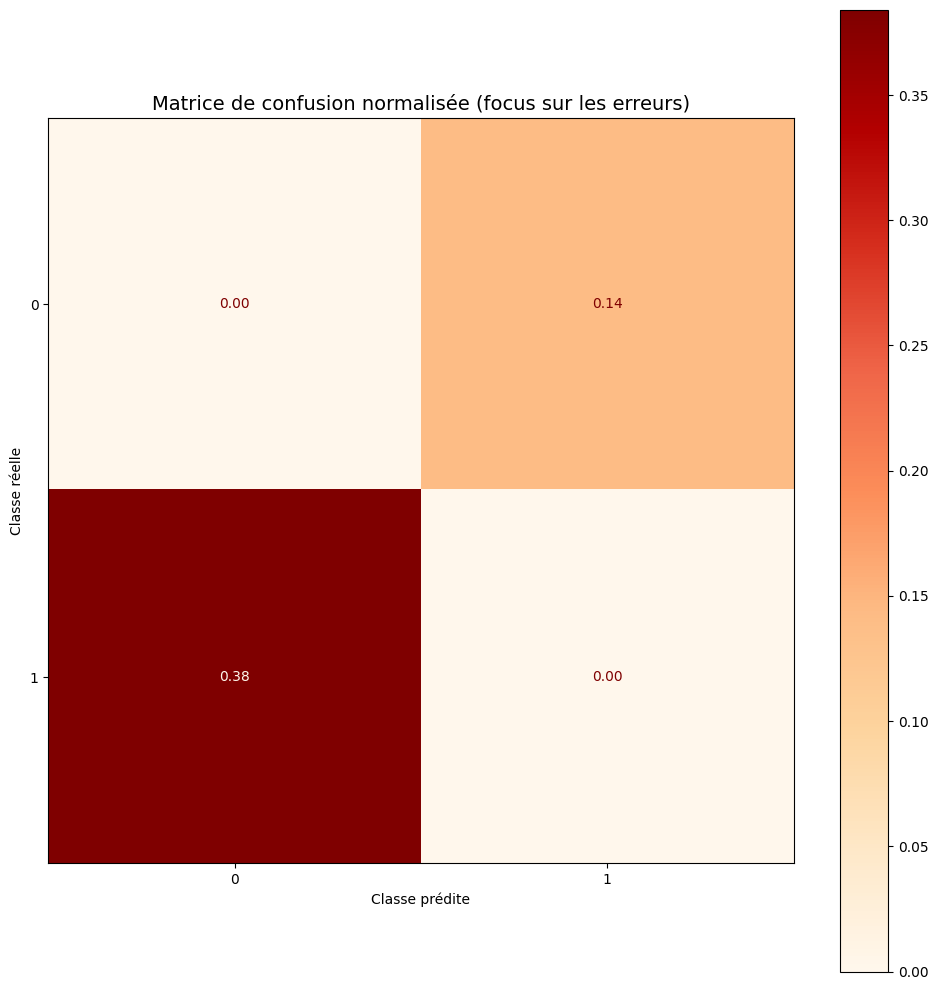

In [ ]:
# Colonnes catégorielles et numériques
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Pipeline complet
sgd_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42))
])

# Entraînement
sgd_clf.fit(X_train, y_train)

# Prédictions sur le jeu d'entraînement
y_pred = sgd_clf.predict(X_train)

# Matrice de confusion multiclasse
matrice_confusion = confusion_matrix(y_train, y_pred)

# Normalisation par ligne
sommes_lignes = matrice_confusion.sum(axis=1, keepdims=True)
matrice_normalisee = matrice_confusion / (sommes_lignes + 1e-9)

# Suppression des bonnes prédictions (diagonale)
np.fill_diagonal(matrice_normalisee, 0)

# Visualisation
disp = ConfusionMatrixDisplay(
    confusion_matrix=matrice_normalisee,
    display_labels=sgd_clf.classes_
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='OrRd', colorbar=True, values_format=".2f")
plt.title("Matrice de confusion normalisée (focus sur les erreurs)", fontsize=14)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()


## 2. Modèle boosté : XGBoost

Le second modèle teste un algorithme de boosting de gradient. XGBoost est réputé
pour sa capacité à capturer des interactions complexes et à bien gérer les données
catégorielles encodées. Nous le comparons à la régression logistique afin
d'évaluer le gain de performance potentiel lié à cette complexité accrue.



🔁 Cross Validation (5 folds)

📊 Résultats Cross Validation (moyenne) :
   Accuracy  : 0.7845
   Precision : 0.6132
   Recall    : 0.5137
   F1-score  : 0.5587
   ROC AUC   : 0.8184

📊 Performance sur jeu de test :
   Accuracy : 0.7989
   ROC AUC  : 0.8343
   F1 score : 0.5893

🔍 Matrice de confusion :
   TN : 921 | FP : 112
   FN : 171 | TP : 203


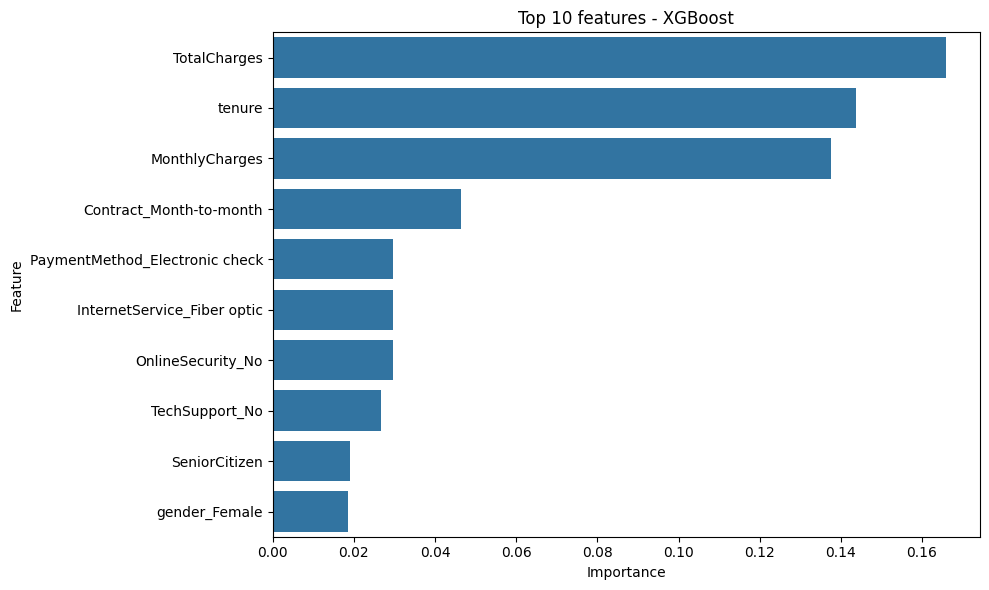

In [ ]:
# ===============================
# 🔁 Cross Validation
# ===============================

print("\n🔁 Cross Validation (5 folds)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\n📊 Résultats Cross Validation (moyenne) :")
print(f"   Accuracy  : {cv_results['test_accuracy'].mean():.4f}")
print(f"   Precision : {cv_results['test_precision'].mean():.4f}")
print(f"   Recall    : {cv_results['test_recall'].mean():.4f}")
print(f"   F1-score  : {cv_results['test_f1'].mean():.4f}")
print(f"   ROC AUC   : {cv_results['test_roc_auc'].mean():.4f}")

# ===============================
# 🎓 Entraînement final
# ===============================

xgb_pipeline.fit(X_train, y_train)

# ===============================
# 🔮 Prédictions
# ===============================

y_pred_xgb_test = xgb_pipeline.predict(X_test)
y_proba_xgb_test = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n📊 Performance sur jeu de test :")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_xgb_test):.4f}")
print(f"   ROC AUC  : {roc_auc_score(y_test, y_proba_xgb_test):.4f}")
print(f"   F1 score : {f1_score(y_test, y_pred_xgb_test):.4f}")

# ===============================
# 🔍 Matrice de confusion
# ===============================

cm = confusion_matrix(y_test, y_pred_xgb_test)

print("\n🔍 Matrice de confusion :")
print(f"   TN : {cm[0,0]} | FP : {cm[0,1]}")
print(f"   FN : {cm[1,0]} | TP : {cm[1,1]}")

# ===============================
# 📌 Importance des variables
# ===============================

feature_names = []
feature_names.extend(num_cols)

ohe = xgb_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
feature_names.extend(ohe.get_feature_names_out(cat_cols))

importances = xgb_pipeline.named_steps["classifier"].feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10,6))
sns.barplot(
    data=imp_rf_df.head(10), 
    x="importance", 
    y="feature", 
    color="#1f77b4"  
)
plt.title("Top 10 features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 3. Modèle bagging : Random Forest

Enfin, un modèle d'ensemble par bagging est évalué. La Random Forest,
moins sensible aux valeurs aberrantes et aux petits déséquilibres, offre un
troisième point de comparaison et permet de vérifier si le gain de
performance reste stable.


ROC AUC CV moyenne : 0.8188 ± 0.0098

📊 Performance Random Forest sur jeu de test :
   Accuracy : 0.7953
   ROC AUC  : 0.8350
   F1 score : 0.5596


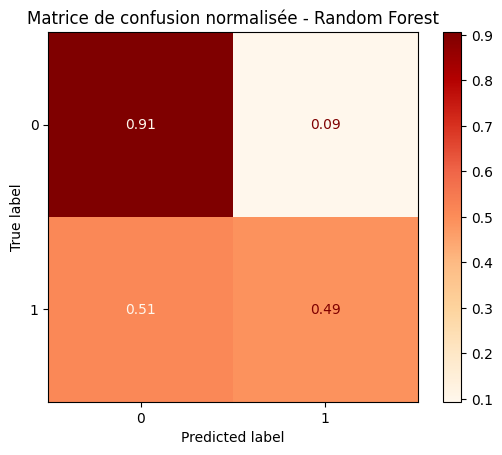

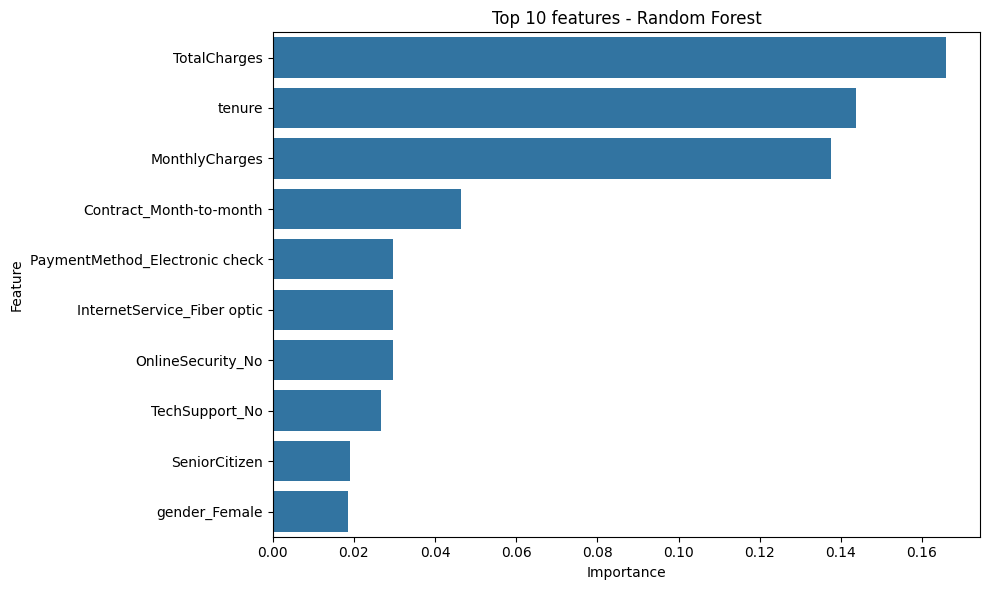

In [53]:
#  Pipeline Random Forest
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),  # déjà défini pour encodage + normalisation
        ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
    ]
)

# Cross-validation stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"ROC AUC CV moyenne : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

#  Entraînement sur tout le jeu d'entraînement
rf_pipeline.fit(X_train, y_train)

#  Prédictions sur le jeu de test
y_pred_rf_test = rf_pipeline.predict(X_test)
y_proba_rf_test = rf_pipeline.predict_proba(X_test)[:, 1]

# Performance
print("\n📊 Performance Random Forest sur jeu de test :")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_rf_test):.4f}")
print(f"   ROC AUC  : {roc_auc_score(y_test, y_proba_rf_test):.4f}")
print(f"   F1 score : {f1_score(y_test, y_pred_rf_test):.4f}")

# Matrice de confusion normalisée
cm = confusion_matrix(y_test, y_pred_rf_test)
cm_normalized = cm / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=rf_pipeline.classes_)
disp.plot(cmap=plt.cm.OrRd, values_format=".2f")
plt.title("Matrice de confusion normalisée - Random Forest")
plt.show()

# Importances des features
importances_rf = rf_pipeline.named_steps["classifier"].feature_importances_

# Si preprocessor transforme les colonnes (OneHotEncoder), récupérer noms exacts
feature_names_num = num_cols
feature_names_cat = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = np.concatenate([feature_names_num, feature_names_cat])

imp_rf_df = pd.DataFrame({"feature": feature_names, "importance": importances_rf})
imp_rf_df = imp_rf_df.sort_values("importance", ascending=False).reset_index(drop=True)

# Top 10 features
plt.figure(figsize=(10,6))
sns.barplot(
    data=imp_rf_df.head(10), 
    x="importance", 
    y="feature", 
    color="#1f77b4"  
)
plt.title("Top 10 features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Interprétation des résultats

- La **régression logistique** offre une excellente simplicité et interprétabilité. Elle atteint un **ROC AUC de ~0.86**, ce qui est un bon niveau pour un modèle de scoring de churn. Les métriques train/test sont proches, ce qui indique peu d'over‑fitting.
- **XGBoost** se comporte légèrement moins bien en termes de AUC/F1 dans cette configuration de base, mais reste compétitif. Les importances montrent l'impact fort des modalités `InternetService` et du type de `Contract`.
- **Random Forest** fournit une troisième référence en bagging. Ses performances intermédiaires (accuracy/AUC/F1) confirment que la simple logistique est déjà très solide ; la RF offre un équilibre entre complexité et gain potentiel et met en évidence des variables similaires aux modèles précédents.


## 4. Conclusion générale

Les trois modèles proposés servent de base pour un outil de scoring churn.
La régression logistique offre un excellent compromis entre performance et
explicabilité. Les modèles d'ensemble (XGBoost, Random Forest) confirment
les tendances observées et fournissent une légère variation de performance.

Pour des déploiements futurs, il convient de :

- Poursuivre le **tuning des hyperparamètres** sur XGBoost et RF.
- Tester des techniques de **sur-échantillonnage/pondération** si le déséquilibre
du churn s'accentue.
- Exporter les pipelines comme artefacts (*joblib*), puis intégrer dans
  `src/train.py` et `src/infer.py` pour la production.

Cette structure claire, inspirée du premier notebook, facilite la lecture
et l'extension par d'autres analystes ou ingénieurs de données.